# Изучение рынка заведений общественного питания Москвы

Заказчик — инвесторы из фонда Shut Up and Take My Money, которые решили попробовать себя в новой области и открыть заведение общественного питания в Москве. Заказчики ещё не знают, что это будет за место: кафе, ресторан или бар. Расположение, меню и цены пока тоже обсуждаются. Для начала заказчики просят нас провести исследовательский анализ рынка Москвы. Эти результаты помогут в выборе подходящего инвесторам места.

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ рынка заведений общественного питания Москвы для выбора подходящего места для открытия нового заведения.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Для анализа используются данные с заведениями общественного питания Москвы, составленные на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

**Описание датасета `rest_info`:**

- `id` — идентификатор заведения;
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым;
- `seats` — количество посадочных мест.

**Описание датасета `rest_price`:**

- `id` — идентификатор заведения;
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽»
    и так далее.
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

In [2]:
# Установим библиотеку phik
!pip install phik -q

In [3]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [4]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('rest_info.csv')
price_df = pd.read_csv('rest_price.csv')

In [5]:
# Выводим первые строки датафрейма rest_info.csv на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [6]:
# Выводим информацию о датафрейме rest_info.csv
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [7]:
# Выводим первые строки датафрейма rest_price.csv на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [8]:
# Выводим информацию о датафрейме rest_price.csv
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

**Датасет `rest_info.csv`** содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов корректны и приведены к стилю snake case.
- 2 столбца имеют тип данных `float64`:   
    - `rating`: содержит информацию о рейтинге заведения по оценкам пользователей в Яндекс Картах, тип `float64` подходит для этих данных, однако с учетом максимального значения 5.0 размерность этих данных можно оптимизировать;    
    - `seats`: содержит информацию о количестве посадочных мест, для этих данных больше подходит тип `int8`. Количество мест - целочисленное, но данные содержат пропуски NaN, в связи с чем установлен тип `float64`.
- Столбец `chain` имеет тип `int64` и содержит значения 1 или 0 — размерность этого столбца можно оптимизировать.
- Остальные 6 столбцов имеют тип данных `object` и содержат строковую информацию (идентификатор заведения, категория цен, информация о днях и часах работы), здесь тип данных `object` подходит.
- Пропуски содержатся в столбцах `hours` и `seats`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

**Датасет `rest_price.csv`** содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов корректны и приведены к стилю snake case.
- 2 столбца имеют тип данных `float64`: `middle_avg_bill` и `middle_coffee_cup`, которые содержат оценку среднего чека и одной чашки капучино. Столбцы содержат пропуски NaN, в связи с чем установлен тип `float64`, однако размерность этого столбца можно оптимизировать.
- Остальные 3 столбца имеют тип данных `object` и содержат строковую информацию (идентификатор заведения, категория цен в заведении, средняя стоимость заказа в виде диапазона), для них тип данных `object` подходит.
- Пропуски содержатся во всех столбцах, кроме `id`. Информация из данного датасета размещена в сервисе Яндекс Бизнес и могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер, поэтому пропуски здесь обоснованы.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

### Подготовка единого датафрейма

In [9]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, on='id', how='left')

In [10]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Данные соединены, и информация обо всех заведениях сохранилась.

---

## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:

- Изучим корректность типов данных и проведем их преобразование.

In [11]:
# Проверим типы данных в датафрейме df с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

In [12]:
# Понизим разрядность для столбцов с float64 до float32
for column in ['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column], downcast='float')

# Оптимизируем целочисленный тип данных до int8
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [13]:
# Проверим типы данных в датафрейме df после преобразования
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

- Изучим пропущенные значения в данных.

In [14]:
# Выводим количество пропущенных строк в датафрейме
df.isna().sum().sort_values()

id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
hours                 536
seats                3611
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [15]:
# Подсчитаем процент строк с пропусками
df.isna().sum().sort_values() / len(df) * 100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
rating                0.000000
chain                 0.000000
hours                 6.376398
seats                42.957411
avg_bill             54.603854
price                60.563883
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

В данных наблюдаются пропуски в следующих столбцах:

- `hours`: в 536 строках (6.38% данных) отсутствует информация о днях и часах работы. Пропуски в этом столбце могут быть вызваны техническим сбоем. Доля таких строк достаточно высокая, их удаление повлияет на результаты исследования.
- `seats`: в 3611 строках (42.96% данных) отсутствует информация о количестве посадочных мест. Пропуски в этом столбце могут быть вызваны тем, что данная информация не предоставлялась сервису Яндекс Карты (например, если это не обязательное для заполнения поле). Доля таких строк слишком высокая, их удаление повлияет на результаты исследования.
- `avg_bill`, `price`, `middle_avg_bill`, `middle_coffee_cup`: информация отсутствует более чем в половине строк, а для столбца `middle_coffee_cup` данные содержатся только для 6.36% строк. Пропуски в этом столбце объясняются справочным характером информации, которая добавляется пользователями или найдена в общедоступных источниках. Доля таких строк слишком высокая, их удаление повлияет на результаты исследования.

---

- Проверим данные на явные и неявные дубликаты.

In [16]:
# Проверяем полные дубликаты в датафрейме
df.duplicated().sum()

0

In [17]:
# Проверяем неявные дубликаты в столбце id
df.duplicated(subset='id').sum()

0

In [18]:
# Удалим лишние пробелы в начале и конце названия заведениия и приведем наименование к нижнему регистру
df['name'] = df['name'].str.strip().str.lower()

In [19]:
# Удалим лишние пробелы в начале и конце адреса заведениия и приведем адрес к нижнему регистру
df['address'] = df['address'].str.strip().str.lower()

In [20]:
# Проверяем неявные дубликаты для данных в столбцах name и address
df.sort_values(by=df.columns.tolist())
df.duplicated(subset=['name', 'address']).sum()

4

In [21]:
# Посмотрим на эти неявные дубликаты
df[df.duplicated(subset=['name', 'address'], keep=False) == True]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


In [22]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['district', 'category', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



В датафрейме нет полных дубликатов строк. Данные в категориальных столбцах `district`, `category`, `price` также не содержат дубликатов.

После нормализации данных в столбцах `name`, `address` были выявлены 4 неявных дубликата. Данные дубликаты не являются полными и содержат различные значения в столбцах `category`, `hours`, `chain`. Это может быть связано с тем, что в датасетах хранятся старые и новые данные о заведениях. Так как отсутствует информация о дате актуализации записи, невозможно выбрать, какая из двух строк является актуальной. С учетом малого количества таких дубликатов данные оставлены как есть.

---

- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - `True` — если заведение работает ежедневно и круглосуточно;
  - `False` — в противоположном случае.

In [23]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком
def create_is_24_7(x):
  
    if pd.isna(x):
        return False
    
    if x.find('ежедневно, круглосуточно') != -1:
        return True
    else:
        return False

In [24]:
# Создаём столбец is_balance с помощью функции create_is_24_7
df['is_24_7'] = df['hours'].apply(create_is_24_7)

---

### Промежуточный вывод

В результате предобработки данных были выполнены следующие действия:

- Для оптимизации работы с данными в датафрейме были скорректированы типы данных столбцов `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup`, `chain` в части понижения разрядности.
- Изучены пропуски в данных. Пропуски обнаружены в 6 столбцах: `hours`, `seats`, `avg_bill`, `price`, `middle_avg_bill`, `middle_coffee_cup`. Количество строк с пропусками достаточно велико, и их удаление может привести к искажению результатов исследования, поэтому такие строки оставлены как есть.
- Данные проверены на явные дубликаты — они отсутствуют. Выявлены 4 неявных дубликата по столбцам `name` и `address`, появление которых, возможно, связано с тем, что в датасетах хранятся старые и новые данные о заведениях. С учетом отсутствия возможности определения, какая информация актуальна, и малого количества таких дубликатов данные оставлены как есть.


## 3. Исследовательский анализ данных

---
### Задача 1

Исследуем количество объектов общественного питания по каждой категории.

In [25]:
# Проверяем распределение данных по значениям столбца category
print('Распределение данных по значениям столбца category:')
df['category'].value_counts()

Распределение данных по значениям столбца category:


кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

Всего в этом столбце 8 уникальных значений, самые популярные категории по убыванию — «кафе», «ресторан» и «кофейня».

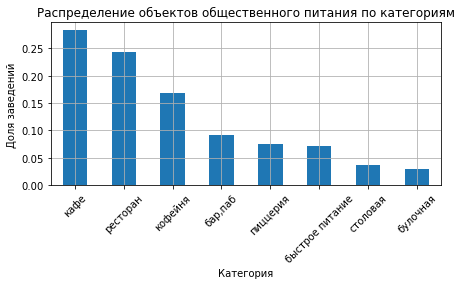

In [26]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение объектов общественного питания по категориям'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из категорий заведений по количеству объектов значительно преобладают три — «кафе», «ресторан» и «кофейня».

---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

In [27]:
# Проверяем распределение данных по значениям столбца district
print('Распределение данных по значениям столбца district:')
df['district'].value_counts()

Распределение данных по значениям столбца district:


Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

В данных присутствует 9 административных районы Москвы, наибольшее число объектов общественного питания сосредоточены в Центральном административном округе (2242), наименьшее - в Северо-Западном административном округе (409). В остальных районах количество заведений примерно одинаковое.

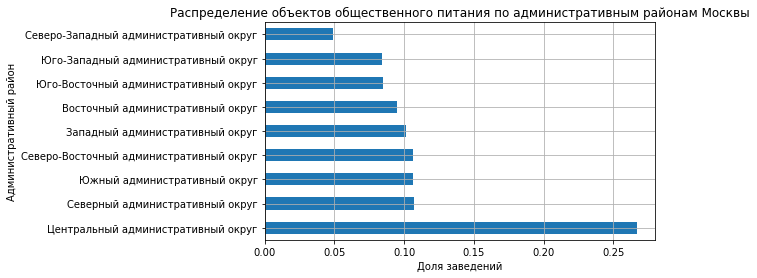

In [28]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['district'].value_counts(normalize=True).plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение объектов общественного питания по административным районам Москвы'
)

# Настраиваем оформление графика
plt.ylabel('Административный район')
plt.xlabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Изучим отдельно распределение заведений каждой категории в Центральном административном округе Москвы:

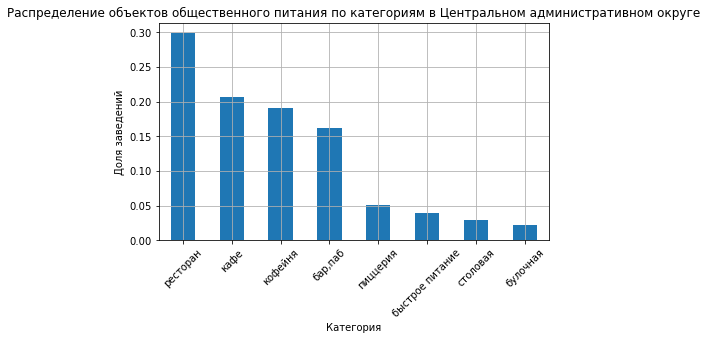

In [29]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df_central = df[df['district'] == 'Центральный административный округ']
df_central['category'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение объектов общественного питания по категориям в Центральном административном округе'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Доля заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

В Центральном административном округе Москвы наиболее популярной категорией заведения является «ресторан», а не «кафе», как по общим данным датасета. «Кафе» занимает второе место по популярности.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

In [30]:
# Проверяем распределение данных по значениям в столбце chain
print('Распределение данных по значениям столбца chain:')
print(df['chain'].value_counts(normalize=True))

Распределение данных по значениям столбца chain:
0    0.618725
1    0.381275
Name: chain, dtype: float64


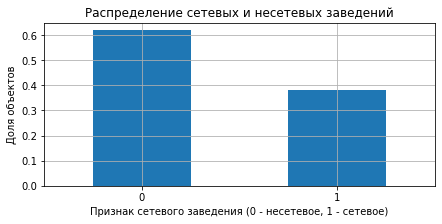

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение сетевых и несетевых заведений'
)

# Настраиваем оформление графика
plt.xlabel('Признак сетевого заведения (0 - несетевое, 1 - сетевое)')
plt.ylabel('Доля объектов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

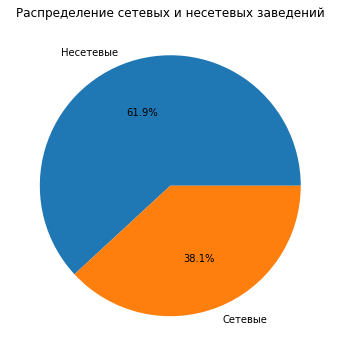

In [63]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(6, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts(normalize=True).plot(
               kind='pie', # Тип графика — столбчатая диаграмма
               autopct='%1.1f%%', #rot=0, # Градус вращения подписи по оси Х 
               labels=['Несетевые', 'Сетевые'], # Выключаем легенду
               legend=False, # Выключаем легенду
               title=f'Распределение сетевых и несетевых заведений'
)

# Настраиваем оформление графика
plt.ylabel('')

# Выводим график
plt.show()

Около 62% объектов общественного питания в Москве являются несетевыми.

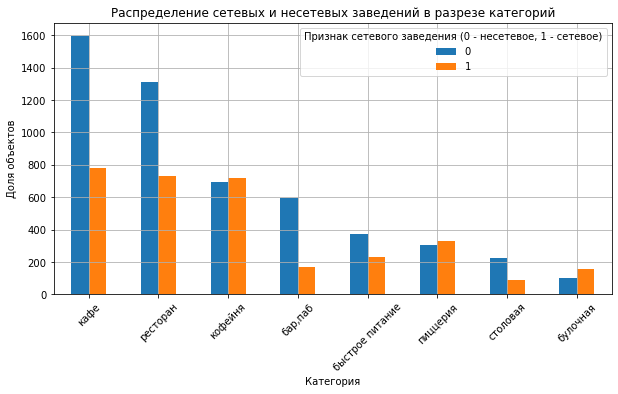

In [33]:
# Построим график столбчатой диаграммы с разделением по признаку chain среди разных категорий заведений
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.sort_values(by=0, ascending=False).plot(kind='bar',
               title=f'Распределение сетевых и несетевых заведений в разрезе категорий',
               ylabel='Доля объектов',
               xlabel='Категория',
               rot=45,
               figsize=(10, 5))
plt.legend(title='Признак сетевого заведения (0 - несетевое, 1 - сетевое)')
plt.grid()

# Выводим график
plt.show()

Как для сетевых, так и для несетевых заведений распределение в разрезе по категориям одинаково: наиболее популярными категориями являются «кафе», «ресторан» и «кофейня».

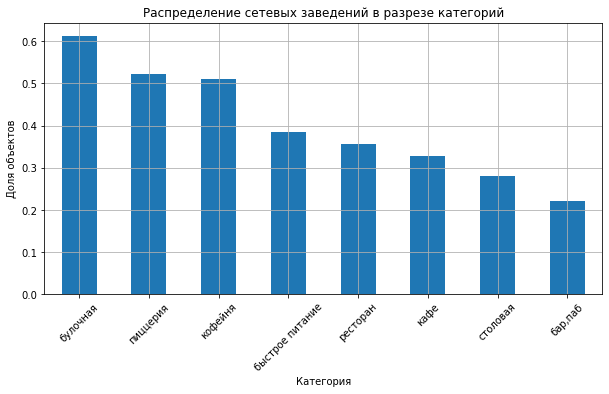

In [34]:
# Построим график столбчатой диаграммы с разделением по категориям для сетевых заведений
grouped = df.groupby('category')['chain'].mean().sort_values(ascending=False)
grouped.plot(kind='bar',
               title=f'Распределение сетевых заведений в разрезе категорий',
               ylabel='Доля объектов',
               xlabel='Категория',
               legend=False,        
               rot=45,
               figsize=(10, 5))
plt.grid()

# Выводим график
plt.show()

Чаще всего сетевыми являются следующие категории заведений: «булочная» (в 61% случаев), «пиццерия» (52%), «кофейня» (51%).

---

### Задача 4

Исследуем количество посадочных мест в заведениях: встречаются ли в данных аномальные значения или выбросы?

In [35]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4795.000000
mean      108.421692
std       122.833374
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

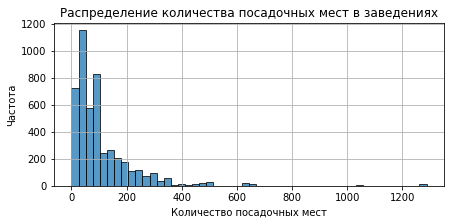

In [36]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

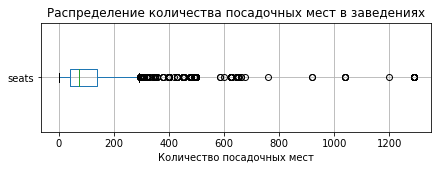

In [37]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')

# Выводим график
plt.show()

Распределение количества посадочных мест в заведениях асимметричное, скошенное вправо. Минимальное количество посадочных мест  — 0, максимальное — 1288, среднее значение соответствует 108 местам, тогда как медиана — 75. Среднее и медианное значения существенно различаются, что свидетельствует о наличии значительного числа выбросов. По диаграмме размаха видно, что значения выше примерно 300 мест можно считать выбросами.

Отсутствие посадочных мест в заведении в целом не является аномалией (например, кофейня навынос, точки продажи фастфуда, булочные, заведения, работающие только на доставку), однако для некоторых категорий заведений (бары, столовые) такие значения вероятнее всего являются ошибочными. Необходимо провести более детальный анализ количества посадочных мест в разрезе категорий.

Очень высокие значения количества мест в заведениях (больше 300) в целом допустимы, однако в большинстве случаев вероятнее всего являются ошибочными. Возможные причины возникновения таких ошибок: человеческий фактор (ошибки при вводе данных), указание сетевыми заведениями одинакового количества мест, суммарного по всем точками сети.

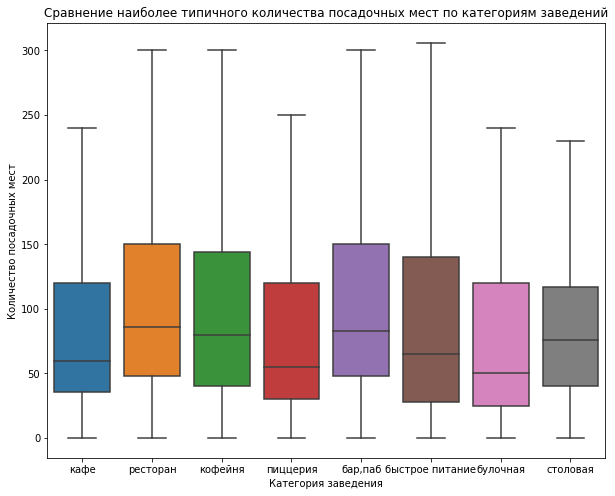

In [38]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 8))

# Строим диаграмму размаха для каждого значения category
sns.boxplot(data=df, y='seats', x='category', showfliers=False)

# Добавляем заголовок и метки оси
plt.title(f'Сравнение наиболее типичного количества посадочных мест по категориям заведений')
plt.xlabel('Категория заведения')
plt.ylabel('Количество посадочных мест')

plt.show()

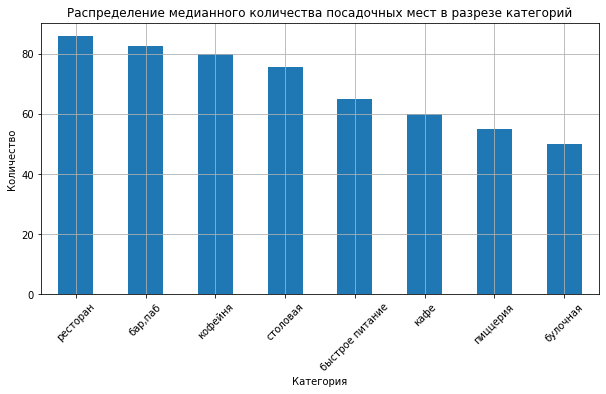

In [39]:
# Построим график столбчатой диаграммы с разделением по категориям
grouped = df.groupby('category')['seats'].median().sort_values(ascending=False)
grouped.plot(kind='bar',
               title=f'Распределение медианного количества посадочных мест в разрезе категорий',
               ylabel='Количество',
               xlabel='Категория',
               legend=False,        
               rot=45,
               figsize=(10, 5))
plt.grid()

# Выводим график
plt.show()

Наиболее типичное количество посадочных мест (находятся внутри «ящиков») для различных категорий незначительно варьируется и находится в диапазоне от 25-50 до 120-150. При этом наименьшее значение для всех категорий одинаково — 0, что может говорить о наличии ошибок в данных для некоторых категорий, таких как «бар/паб», «столовая». 

Аномалии в количестве посадочных мест могут являться следствием неверной категоризации заведений, а также ошибками данных.

---

### Задача 5

Исследуем распределение средних рейтингов по категориям заведений.

In [40]:
# Изучаем статистические показатели столбца rating
print('Статистические показатели столбца rating:')
df['rating'].describe()

Статистические показатели столбца rating:


count    8406.000000
mean        4.229911
std         0.470342
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

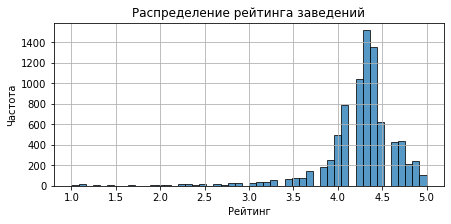

In [41]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['rating'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение рейтинга заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

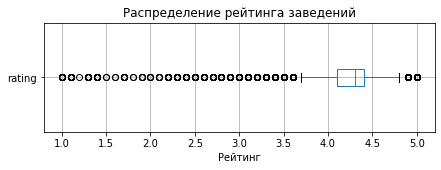

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце rating
df.boxplot(column='rating', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение рейтинга заведений')
plt.xlabel('Рейтинг')

# Выводим график
plt.show()

Распределение рейтинга заведений асимметричное, скошенное влево. Минимальный рейтинг  — 1.0, максимальный — 5.0. Средний рейтинг — 4.2, медиана — 4.3. Среднее и медианное значение достаточно близки. По гистограмме размаха видно, что рейтинги ниже примерно 3.7 можно считать выбросами. Однако такие оценки являются корректными, поэтому не будем их исключать из дальнейшего анализа.

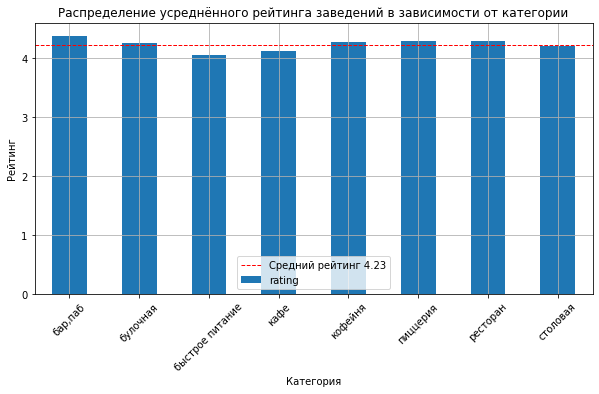

In [43]:
# Строим график столбчатой диаграммы
grouped = df.groupby('category')['rating'].mean()
grouped.plot(kind='bar',
               title=f'Распределение усреднённого рейтинга заведений в зависимости от категории',
               legend=True,
               ylabel='Рейтинг',
               xlabel='Категория',
               rot=45,
               figsize=(10, 5))

# Рассчитываем среднее значение рейтинга
mean_rating = round(df['rating'].mean(), 2)

# Наносим на график линию с средним значением рейтинга
plt.axhline(mean_rating, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Средний рейтинг {mean_rating:.2f}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

Видно, что нет чёткой зависимости между категорией заведения и его средним рейтингом. Все значения находятся примерно около среднего, однако можно отметить, что заведения категорий «кафе» и «быстрое питание» в среднем имеют рейтинг немного ниже общего среднего, а «бар,паб» — выше общего среднего.

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Выберем самую сильную связь и проверим её.

In [44]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats',
                         'price', 'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198949
district,0.189389
is_24_7,0.160804
chain,0.119071
seats,0.000000


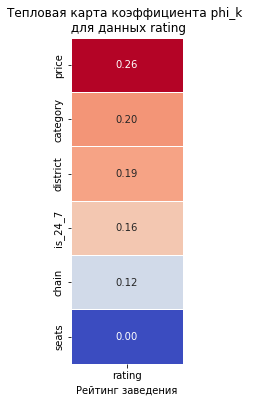

In [45]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками заведений
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')

# Выводим график
plt.show()

Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорей (0.26). Для остальных признаков коэффициент корреляции снижается с 0.20 до 0. Проверим связь рейтинга заведения с его ценовой категорией.

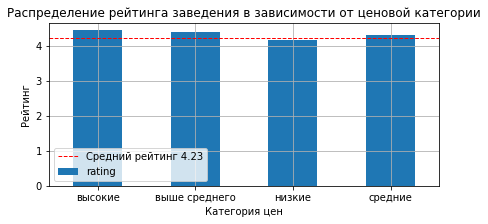

In [46]:
# Строим график столбчатой диаграммы
grouped = df.groupby('price')['rating'].mean()
grouped.plot(kind='bar',
               title=f'Распределение рейтинга заведения в зависимости от ценовой категории',
               legend=True,
               ylabel='Рейтинг',
               xlabel='Категория цен',
               rot=0,
               figsize=(7, 3))

# Рассчитываем среднее значение рейтинга
mean_rating = df['rating'].mean()

# Наносим на график линию с средним значением рейтинга
plt.axhline(mean_rating, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Средний рейтинг {mean_rating:.2f}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

Видно, что нет чёткой зависимости между рейтингом заведения и категорией цен. Значения находятся примерно около среднего.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе.

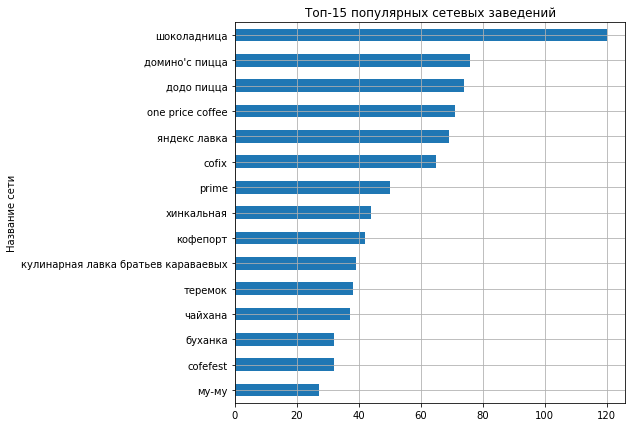

In [47]:
# Найдем топ-15 популярных сетей в Москве
grouped = df[df['chain'] == 1].groupby(['name'])['id'].count().reset_index(name='count')
grouped_sort = grouped.sort_values(by='count', ascending=False).head(15)
grouped_sort = grouped_sort.sort_values(by='count')
# Строим график столбчатой диаграммы
grouped_sort.plot(kind='barh', x='name', y='count',
               title=f'Топ-15 популярных сетевых заведений',
               legend=False,
               ylabel='Количество заведений',
               xlabel='Название сети',
               rot=0,
               figsize=(7, 7))

plt.grid()

# Выводим график
plt.show()

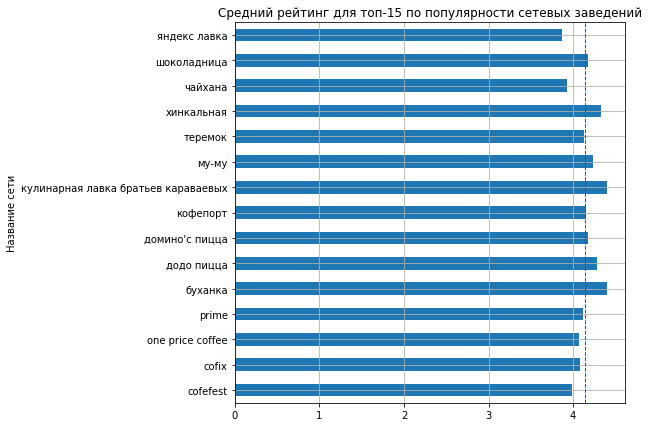

In [48]:
# Выполним внутреннее соединение с исходным датафреймом для фильтрации заведений
top_df = df[df['chain'] == 1].merge(grouped_sort, on='name')

# Строим график столбчатой диаграммы среднего рейтинга заведений из топ-15
grouped_top = top_df.groupby('name')['rating'].mean()
grouped_top.plot(kind='barh',
               title=f'Средний рейтинг для топ-15 по популярности сетевых заведений',
               legend=False,
               ylabel='Рейтинг',
               xlabel='Название сети',
               rot=0,
               figsize=(7, 7))

# Рассчитываем среднее значение рейтинга
mean_rating = top_df['rating'].mean()

# Наносим на график линию с средним значением рейтинга
plt.axvline(mean_rating, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1) # Ширина линии

plt.grid()

# Выводим график
plt.show()

Сетевые заведения из топ-15 по поулярности имеют средний рейтинг, близкий к общему среднему рейтингу по всем заведениям общественного питания, но можно отметить сети с рейтингом ниже 4: «Cofefest», «Чайхана» и «Яндекс лавка».

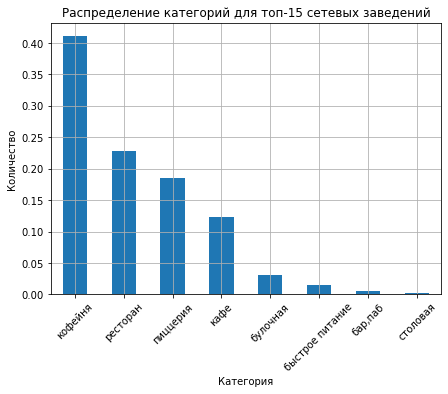

In [49]:
# Строим график столбчатой диаграммы категорий заведений из топ-15
top_df['category'].value_counts(normalize=True).plot(kind='bar',
               title=f'Распределение категорий для топ-15 сетевых заведений',
               ylabel='Количество',
               xlabel='Категория',
               rot=45,
               figsize=(7, 5))

plt.grid()

# Выводим график
plt.show()

Наиболее распространенная категория среди топ-15 сетевых заведений — «кофейня», их доля составляет 41% от общего числа.

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других.

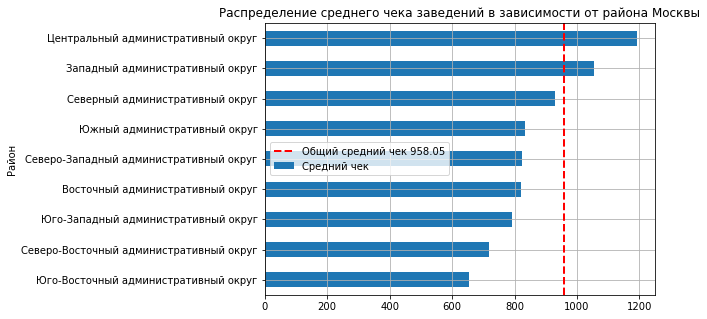

In [50]:
# Строим график столбчатой диаграммы
grouped = df.groupby('district')['middle_avg_bill'].mean().sort_values()
grouped.plot(kind='barh',
               title=f'Распределение среднего чека заведений в зависимости от района Москвы',
               legend=True, label='Средний чек',
               ylabel='Средний чек',
               xlabel='Район',
               rot=0,
               figsize=(7, 5))

# Рассчитываем общее среднее значение чека
mean_avg_bill = round(df['middle_avg_bill'].mean(), 2)

# Наносим на график линию с средним значением чека
plt.axvline(mean_avg_bill, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=2, # Ширина линии
            label=f'Общий средний чек {mean_avg_bill:.2f}')

plt.grid()
plt.legend()

# Выводим график
plt.show()

По графику видно, что в Центральном административном округе самый высокий средний чек (1191 р.), существенно превышающий общий средний чек (958 р.). Единственным районом, помимо ЦАО, где средний чек превышает общий, является Западный административный район (1053 р.). Во всех остальных районах значение среднего чека ниже общего, причем в Северо-Восточном и Юго-Восточном административных округах — существенно ниже (717 р. и 654 р. соответственно). Также можно отметить, что средний чек напрямую зависит от удаленности административного района от центра Москвы.

---

### Промежуточный вывод

Анализ данных показал, что:

- Наиболее популярными категориями заведений общественного питания в Москве являются «кафе», «ресторан» и «кофейня», при этом в Центральном административном районе категория «ресторан» более популярна, чем «кафе».
- Наибольшее число объектов общественного питания сосредоточены в Центральном административном округе, наименьшее — в Северо-Западном административном округе, в остальных районах количество заведений примерно одинаковое.
- Около 62% объектов общественного питания в Москве являются несетевыми, чаще всего сетевыми являются категории заведений «булочная» (в 61% случаев), «пиццерия» (52%), «кофейня» (51%).
- Наиболее типичное количество посадочных мест для различных категорий заведения находится в диапазоне от 25-50 до 120-150 в зависимости от категории заведения.
- Средний рейтинг заведений — 4.23. Зависимость между средним рейтингом заведения и его категорией или категорией цен отсутствует.
- Средний чек — 958 р. Сумма среднего чека напрямую зависит от удаленности административного района от центра Москвы: в Центральном административном округе самый высокий средний чек (1191 р.), в Западном — также выше среднего (1053 р.). Во всех остальных районах значение среднего чека ниже общего.

## 4. Итоговый вывод и рекомендации


### Общий обзор проделанной работы

В ходе исследования были проанализированы данные 8406 заведений общественного питания Москвы, составленные на основе сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные содержали общую информацию о заведениях общественного питания, а также справочную информацию о среднем чеке в заведениях. Были выявлены 4 неявных дубликата по столбцам с названием и адресом заведения, появление которых, возможно, связано с тем, что в датасетах хранятся старые и новые данные о заведениях. Также выявлены заведения, для которых указазаны очень высокие значения количества мест в заведениях (больше 300), такие аномалии могут являться следствием неверной категоризации заведений, а также ошибками в данных.

### Ответы на исследовательские вопросы

- Больше всего заведений общественного питания размещены в Центральном административном округе — 2242 из 8406 (27% от общего числа), меньше всего заведений в Северо-Западном административном округе — 409 (5%). 
- Наиболее распространенными категориями являются «кафе» (28%), «ресторан» (24%) и «кофейня» (17%).
- Рейтинг заведения не зависит от его категории или категории цен.
- Сумма среднего чека напрямую зависит от удаленности административного района от центра Москвы.

### Рекомендации на основе анализа данных

С учетом большого числа заведений в Центральном административном округе можно рекомендовать рассмотреть вариант открытия заведения общественного питания в районах Москвы, более удаленных от центра. Например, в Северо-Западном административном округе, где наименьшее количество заведений (5% от общего числа), при этом средний чек (822 р.) не сильно ниже общего среднего чека (958 р.). Или обратить внимание на Западный административный округ, где количество заведений в 2,5 раза меньше, чем в Центральном, но при этом средний чек (1053 р.) выше общего среднего. 

При выборе категории открываемого заведения можно рекомендовать выбрать какую-то из наиболее популярных: «кафе», «ресторан» или «кофейня».